<div style="background-color:#000047; padding: 30px; border-radius: 10px; color: white; text-align: center;">
    <img src='Figures/alinco_white_text.png' style="height: 100px; margin-bottom: 10px;"/>
    <h1>Aprendizaje Automático Avanzado</h1>
    <h3>Gradient Boosting: XGBoost, LightGBM y CatBoost</h3>
</div>

## ¿Qué es el Boosting?

El **boosting** es una técnica de **ensamble** (*ensemble learning*): combina muchos modelos **débiles** (normalmente árboles de decisión pequeños) para formar un modelo **fuerte**.

A diferencia del *bagging* (Random Forest), donde los árboles se entrenan **en paralelo e independientes**, en boosting los árboles se entrenan **en secuencia**, y cada nuevo árbol **corrige los errores** del anterior.

```
   BAGGING (Random Forest)              BOOSTING (Gradient Boosting)

   Árbol 1 ┐                            Árbol 1 ─▶ errores ─▶ Árbol 2 ─▶ errores ─▶ Árbol 3
   Árbol 2 ├─▶ promedio/voto                          (cada uno corrige al anterior)
   Árbol 3 ┘                                                    │
   (en paralelo)                                     Suma ponderada = predicción final
```

[Paper: Benchmarking state-of-the-art gradient boosting
algorithms for classification](https://arxiv.org/pdf/2305.17094)

## Gradient Boosting: la intuición

El **Gradient Boosting** construye el modelo de forma **aditiva**. En cada iteración añade un árbol que apunta en la dirección que **más reduce el error** (el gradiente negativo de la función de pérdida).

$$F_{m}(x) = F_{m-1}(x) + \eta \, h_m(x)$$

donde:
- $F_{m}(x)$ es el modelo en la iteración $m$,
- $h_m(x)$ es el nuevo árbol que se ajusta a los **residuos** (errores),
- $\eta$ es la **tasa de aprendizaje** (*learning rate*), que controla cuánto contribuye cada árbol.

```
   Predicción inicial (media)
            │
            ▼
   residuo = y - predicción ──▶ entrenar árbol sobre el residuo
            │                              │
            └──────────  actualizar  ◀─────┘   (repetir M veces)
```

> "Gradient" viene de que usa el **descenso de gradiente** para minimizar la pérdida, pero en el espacio de funciones (árboles).

### El algoritmo de Gradient Boosting paso a paso

Formalmente, dado un conjunto de entrenamiento $\{(x_i, y_i)\}_{i=1}^{n}$ y una función de pérdida diferenciable $L(y, F(x))$, el algoritmo es:

**1. Inicializar** el modelo con una constante:
$$F_0(x) = \arg\min_{\gamma} \sum_{i=1}^{n} L(y_i, \gamma)$$
(para MSE es la **media** de $y$; para *log-loss*, el *log-odds*).

**2. Para** $m = 1, 2, \dots, M$:

&nbsp;&nbsp;&nbsp;**(a)** Calcular los **pseudo-residuos** (gradiente negativo de la pérdida):
$$r_{im} = -\left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F=F_{m-1}}$$

&nbsp;&nbsp;&nbsp;**(b)** Ajustar un **árbol de regresión** $h_m(x)$ a los pseudo-residuos $r_{im}$, creando regiones (hojas) $R_{jm}$.

&nbsp;&nbsp;&nbsp;**(c)** Calcular el valor óptimo de cada hoja mediante *line search*:
$$\gamma_{jm} = \arg\min_{\gamma} \sum_{x_i \in R_{jm}} L\big(y_i,\, F_{m-1}(x_i) + \gamma\big)$$

&nbsp;&nbsp;&nbsp;**(d)** **Actualizar** el modelo con la tasa de aprendizaje $\eta$:
$$F_m(x) = F_{m-1}(x) + \eta \sum_j \gamma_{jm}\,\mathbb{1}(x \in R_{jm})$$

**3. Salida:** el modelo final $F_M(x)$.

> Para MSE, el pseudo-residuo se reduce a $r_{im} = y_i - F_{m-1}(x_i)$, es decir, el **residuo ordinario**. Por eso decimos que *"cada árbol se ajusta a los errores del anterior"*.


### Funciones de pérdida comunes

La flexibilidad del Gradient Boosting viene de que **cualquier pérdida diferenciable** sirve: basta con cambiar el gradiente que se usa como pseudo-residuo.

| Tarea | Pérdida | $L(y, F)$ | Pseudo-residuo $-\partial L/\partial F$ |
|---|---|---|---|
| Regresión | MSE (L2) | $\tfrac{1}{2}(y-F)^2$ | $y - F$ |
| Regresión robusta | MAE (L1) | $\lvert y-F\rvert$ | $\text{sign}(y - F)$ |
| Regresión robusta | Huber | mixta L1/L2 | residuo acotado |
| Clasificación binaria | Log-loss | $\log(1+e^{-yF})$ | $y - \sigma(F)$ |
| Clasificación multiclase | Cross-entropy (softmax) | $-\sum_k y_k \log p_k$ | $y_k - p_k$ |
| Ranking | LambdaRank / pairwise | — | gradientes por pares |

> 💡 **MSE** es sensible a *outliers* (eleva el error al cuadrado); **MAE** y **Huber** son más robustas. Elegir la pérdida adecuada es parte del diseño del modelo.


### Demostración: el error baja árbol a árbol

Visualicemos las dos ideas clave: 
- (1) el error de test **disminuye** al añadir árboles, y
- (2) el modelo **ajusta progresivamente** la función objetivo.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Datos sintéticos no lineales: y = sin(x) + ruido
rng = np.random.RandomState(0)
X = np.linspace(0, 10, 400).reshape(-1, 1)
y = np.sin(X).ravel() + 0.3 * rng.randn(400)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)


In [3]:
Xtr.shape, ytr.shape

((280, 1), (280,))

In [4]:
#Modelo
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=0)
gbr.fit(Xtr, ytr)

# staged_predict devuelve la predicción tras CADA árbol



,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [5]:
gbr.staged_predict(Xte)

<generator object GradientBoostingRegressor.staged_predict at 0x000001A283F8A810>

In [6]:
test_err = [mean_squared_error(yte, y_pred) for y_pred in gbr.staged_predict(Xte)]
test_err

[0.40052749408412575,
 0.3451654115839799,
 0.3015052235106031,
 0.26466746568159694,
 0.23506736187834978,
 0.21025106788747724,
 0.18993196926110917,
 0.17416675582528623,
 0.15628727623800304,
 0.14235166772790311,
 0.13355395282774798,
 0.12534775906896053,
 0.11930565374625426,
 0.11428842127741769,
 0.11001051846771173,
 0.10618968824460652,
 0.10308607420423616,
 0.10069191312486955,
 0.09970082131675356,
 0.0968318588134563,
 0.09444813931756917,
 0.09274081449364435,
 0.09215388639161588,
 0.09156136286891298,
 0.09109471543966272,
 0.09130442760955801,
 0.09089978023271574,
 0.09123742876871285,
 0.09110638425831893,
 0.09082249051056551,
 0.0909410486913258,
 0.09025104056571315,
 0.09013448094757627,
 0.09057813148488256,
 0.09057127406472319,
 0.0909160918321423,
 0.09075476117061644,
 0.09042606200303235,
 0.09022267058768903,
 0.0903259863591214,
 0.09017539503255703,
 0.09019656483867874,
 0.0906815356801452,
 0.0907055972248896,
 0.09107413752571177,
 0.091404442125395

In [7]:
len(test_err)

100

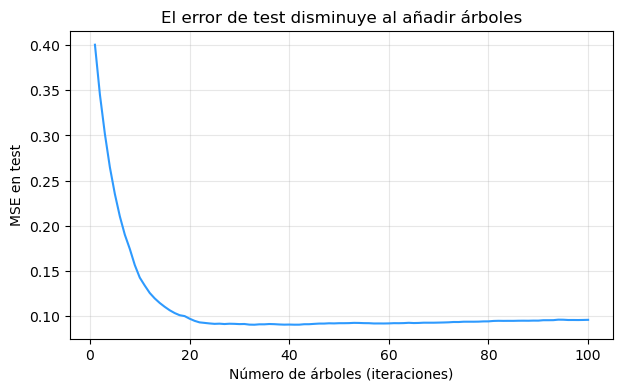

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, 101), test_err, color='#2E9AFE')
plt.xlabel('Número de árboles (iteraciones)')
plt.ylabel('MSE en test')
plt.title('El error de test disminuye al añadir árboles')
plt.grid(alpha=0.3)
plt.show()

In [10]:
order = np.argsort(Xtr.ravel())
order

array([179,  74, 145, 271, 157, 109, 130,  19, 103, 142,   6, 177,  91,
       255,  73, 229,  66,  22, 235, 236,  42,  45,  87, 161, 224, 261,
       102, 164, 219, 178,  93,  57, 278, 193, 166,  70, 225, 215, 163,
        49, 173,  12,  90, 191, 265, 108, 253,  61, 132, 148, 105, 155,
       211, 118, 206,  48, 159, 266, 264, 210,   0,  96, 186, 188,  47,
       182, 246,  15,  25, 116, 220,  56, 133, 126,  97,  33,  23, 251,
        29, 277, 121, 213,  31, 207, 171, 147,  37, 237, 227,  95, 175,
       200,  41,  35,  62,  80, 137,   5, 198, 242, 197, 127,  10, 232,
       129,  76, 128, 115, 117,  44, 231,  20, 256,  98,  50,   9, 190,
       279, 259, 245, 184, 199,  67, 153, 230, 149, 238,  21, 176, 123,
       119, 276, 262,  17, 273, 249,  38,  52, 180, 234, 205,  88, 135,
       194, 124, 167,  65, 270,  77, 111,  34,  75,  14,  82,  64,  79,
       172,   1,  60, 143, 196, 114,  54,  46,   3,   2,  28,  81, 138,
        86,  13,  94, 268, 250, 233,  27, 140, 106, 274,   7, 12

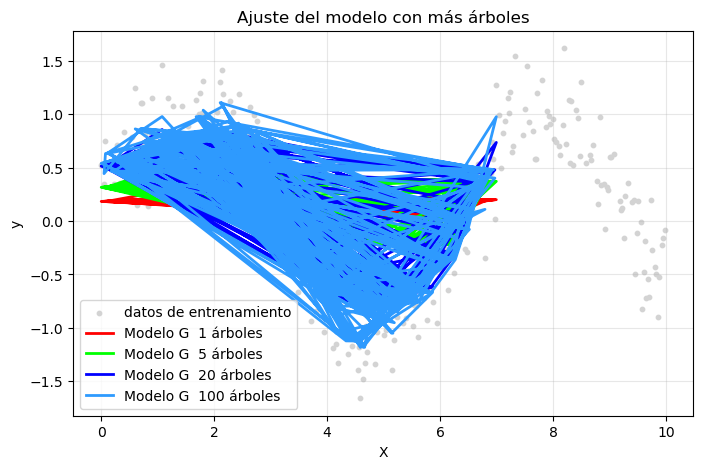

In [13]:
# Cómo mejora el ajuste con más árboles

plt.figure(figsize=(8, 5))
plt.scatter(Xtr, ytr, s=10, color='lightgray', label='datos de entrenamiento')

for n, color in zip([1, 5, 20, 100], ['#FF0000', '#00FF00', '#0000FF', '#2E9AFE']):
    gbr_m = GradientBoostingRegressor(n_estimators=n, learning_rate=0.1, max_depth=3, random_state=0).fit(Xtr, ytr)
    plt.plot(X[order], gbr_m.predict(X[order]), color=color, lw=2, label=f'Modelo G  {n} árboles')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Ajuste del modelo con más árboles')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


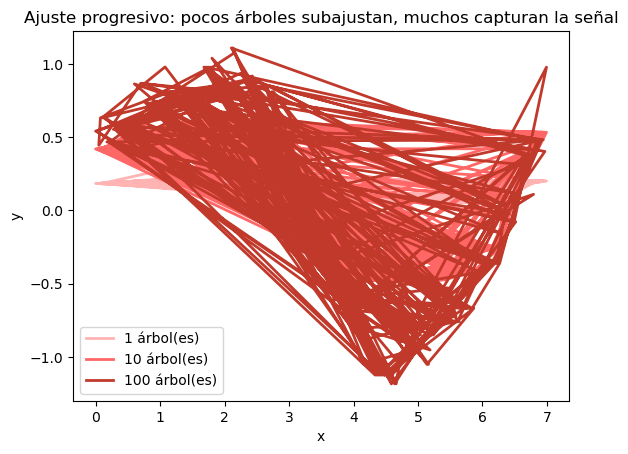

In [15]:
for n, color in [(1, '#ffb3b3'), (10, '#ff6666'), (100, '#c0392b')]:
    m = GradientBoostingRegressor(n_estimators=n, learning_rate=0.1, max_depth=3).fit(Xtr, ytr)
    plt.plot(X[order], m.predict(X)[order], color=color, lw=2, label=f'{n} árbol(es)')

plt.legend()
plt.title('Ajuste progresivo: pocos árboles subajustan, muchos capturan la señal')
plt.xlabel('x'); plt.ylabel('y')
plt.show()

## 3.Librerías disponibles

Aunque todas implementan gradient boosting, cada una introduce optimizaciones propias:

| Característica | **XGBoost** | **LightGBM** | **CatBoost** |
|---|---|---|---|
| Creador | DMLC (2014) | Microsoft (2017) | Yandex (2017) |
| Crecimiento del árbol | Por nivel (*level-wise*) | Por hoja (*leaf-wise*) | Árboles simétricos (*oblivious*) |
| Velocidad | Alta | **Muy alta** (grandes datos) | Alta |
| Variables categóricas | Requiere codificación | Soporte nativo | **Soporte nativo excelente** |
| Regularización | L1/L2 | L1/L2 | L2 + *ordered boosting* |
| Fortaleza | Robusto y probado | Escala a millones de filas | Menos *tuning*, evita *overfitting* |

### ¿Cuál elegir?
- **XGBoost:** opción robusta y estándar de la industria.
- **LightGBM:** cuando tienes **muchísimos datos** y necesitas velocidad.
- **CatBoost:** cuando tienes **muchas variables categóricas** y quieres buenos resultados con poco ajuste.

### XGBoost en profundidad (eXtreme Gradient Boosting)

XGBoost lleva el gradient boosting clásico un paso más allá con varias innovaciones:

- **Objetivo regularizado.** Minimiza la pérdida **más** una penalización por la complejidad de cada árbol:
$$\mathcal{L} = \sum_i L(y_i, \hat{y}_i) + \sum_k \Omega(f_k), \qquad \Omega(f) = \gamma\,T + \tfrac{1}{2}\lambda\lVert w\rVert^2$$
donde $T$ es el número de hojas y $w$ los pesos de las hojas. Esto **combate el sobreajuste** directamente en la función objetivo.

- **Aproximación de segundo orden (Taylor).** En cada split usa el **gradiente** $g_i$ y el **hessiano** $h_i$ de la pérdida. El peso óptimo de una hoja es:
$$w_j^* = -\frac{\sum_{i \in j} g_i}{\sum_{i \in j} h_i + \lambda}$$
y la **ganancia** de un split se calcula con esa fórmula, permitiendo podar ramas poco útiles (parámetro $\gamma$).

- **Sparsity-aware split finding:** maneja valores faltantes aprendiendo una **dirección por defecto** en cada nodo.
- **Weighted Quantile Sketch:** propone puntos de corte de forma eficiente en datasets grandes.
- **Crecimiento por nivel** (*level-wise*) con submuestreo de filas (`subsample`) y columnas (`colsample_bytree`), al estilo de Random Forest.


### LightGBM en profundidad (Light Gradient Boosting Machine)

Diseñado por Microsoft para **velocidad y escala** en datasets grandes:

- **Histogram-based:** agrupa los valores continuos en *bins* discretos, así los splits se evalúan sobre histogramas → **mucho más rápido** y menos memoria.
- **Crecimiento por hoja** (*leaf-wise* con límite de profundidad): expande la hoja con **mayor ganancia**, no todo el nivel. Converge más rápido, pero puede sobreajustar en datos pequeños (se controla con `num_leaves` y `min_child_samples`).
- **GOSS (Gradient-based One-Side Sampling):** conserva todas las instancias con **gradiente grande** (mal predichas) y muestrea las de gradiente pequeño → menos datos por iteración sin perder precisión.
- **EFB (Exclusive Feature Bundling):** agrupa variables dispersas mutuamente excluyentes en una sola → reduce dimensionalidad.
- **Soporte nativo de categóricas** mediante `categorical_feature`.

```
   Level-wise (XGBoost)              Leaf-wise (LightGBM)
          ●                                 ●
         / \                               / \
        ●   ●                             ●   ●
       /|   |\                           /
      ● ●   ● ●                         ●   ← expande solo la hoja
   (crece todo el nivel)                     de mayor ganancia
```


### CatBoost en profundidad (Categorical Boosting)

Diseñado por Yandex, destaca en **variables categóricas** y en robustez frente al sobreajuste:

- **Ordered Target Statistics:** codifica las categóricas usando el *target*, pero con un esquema **ordenado** que solo emplea ejemplos "anteriores" para evitar la **fuga de información** (*target leakage*).
- **Ordered Boosting:** combate el **prediction shift** (el sesgo de usar los mismos datos para estimar el gradiente y ajustar el árbol) entrenando con permutaciones de los datos.
- **Árboles simétricos / oblivious:** todos los nodos de un mismo nivel usan la **misma condición de split**. Esto produce árboles balanceados, predicción **muy rápida** y una regularización implícita.
- **Menos *tuning*:** suele dar excelentes resultados con los parámetros por defecto.


**En resumen:**
1. **XGBoost** = robusto y preciso; 
2. **LightGBM** = rápido y escalable;
3. **CatBoost** = fuerte con categóricas y poco ajuste.


Las tres bibliotecas se instalan con `pip`. `scikit-learn` ya incluye una implementación propia (`HistGradientBoostingClassifier`) que usaremos como base sin instalar nada.

!pip install xgboost lightgbm catboost --user

## Ejemplo base con scikit-learn

Empezamos con el gradient boosting **incluido en scikit-learn** para tener una referencia que siempre corre.

In [16]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Dataset tabular de clasificación binaria


In [17]:
X, y = load_breast_cancer(return_X_y=True)
X

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [18]:
X.shape, y.shape

((569, 30), (569,))

In [21]:
gb = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.1, max_depth=3, random_state=42)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((455, 30), (455,), (114, 30), (114,))

In [23]:
gb.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,max_iter,200
,max_leaf_nodes,31
,max_depth,3
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [24]:
y_test

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0])

In [25]:
y_pred_test = gb.predict(X_test)

In [26]:
accuracy = accuracy_score(y_test, y_pred_test)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.9649


## XGBoost

Ejecuta esta celda si instalaste `xgboost`. Usa la API compatible con scikit-learn.

In [42]:
try:
    from xgboost import XGBClassifier
    #Modelo xgb
    xgb = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=4, random_state=42, eval_metric='logloss')
    xgb.fit(X_train, y_train)

    print('Accuracy (XGBoost):', accuracy_score(y_test, xgb.predict(X_test)))
except ImportError:
    print('xgboost no está instalado. Ejecuta: pip install xgboost')

Accuracy (XGBoost): 0.956140350877193


## LightGBM

In [43]:
try:
    from lightgbm import LGBMClassifier
    #Modelo lgbm
    lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.1, num_leaves=31, random_state=42)
    lgbm.fit(X_train, y_train)

except ImportError:
    print('lightgbm no está instalado. Ejecuta: pip install lightgbm')

[LightGBM] [Info] Number of positive: 286, number of negative: 169
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000539 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4548
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.628571 -> initscore=0.526093
[LightGBM] [Info] Start training from score 0.526093
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

## CatBoost

In [44]:
try:
    from catboost import CatBoostClassifier
    #Modelo catboost
    cat = CatBoostClassifier(iterations=300, learning_rate=0.1, depth=4, random_seed=42, verbose=0)
    cat.fit(X_train, y_train)

    print('Accuracy (CatBoost):', accuracy_score(y_test, cat.predict(X_test)))

except ImportError:
    print('catboost no está instalado. Ejecuta: pip install catboost')

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

## Otros Ejemplos

Hasta aquí clasificamos con las tres bibliotecas. Ahora veamos casos de uso más completos.

### Gradient Boosting para **regresión**

El boosting no es solo para clasificación: cambiando la pérdida, predice valores continuos. Usamos el dataset *California Housing* para predecir el precio de la vivienda.


In [45]:
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

Xr, yr = fetch_california_housing(return_X_y=True)



In [33]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=42)
Xr_train.shape, yr_train.shape

((16512, 8), (16512,))

In [34]:
reg = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.1, max_depth=3, random_state=42)
reg

,loss,'squared_error'
,quantile,None
,learning_rate,0.1
,max_iter,500
,max_leaf_nodes,31
,max_depth,3
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'


In [36]:
reg.fit(Xr_train, yr_train)

,loss,'squared_error'
,quantile,None
,learning_rate,0.1
,max_iter,500
,max_leaf_nodes,31
,max_depth,3
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'


In [37]:
reg.predict(Xr_test)

array([0.52174645, 1.06231527, 4.48457489, ..., 4.95163533, 0.74911088,
       1.80638628], shape=(4128,))

In [39]:
r2_score(yr_test, reg.predict(Xr_test))


0.8255098599083088

### Early stopping con conjunto de validación

Con muchos árboles el modelo puede sobreajustar. El *early stopping* **detiene el entrenamiento** cuando la métrica de validación deja de mejorar, eligiendo automáticamente el número óptimo de árboles.


In [46]:
# Early stopping con XGBoost (usa el conjunto de test como validación)
try:
    from xgboost import XGBClassifier
    xgb_es = XGBClassifier(
        n_estimators=1000, learning_rate=0.05, max_depth=4,
        early_stopping_rounds=30, eval_metric='logloss', random_state=42
    )
    xgb_es.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    print('Mejor iteración (árboles usados):', xgb_es.best_iteration)
    print('Accuracy:', accuracy_score(y_test, xgb_es.predict(X_test)))
except ImportError:
    print('xgboost no está instalado. Ejecuta: pip install xgboost')
except TypeError:
    # Compatibilidad con versiones antiguas de xgboost
    print('Actualiza xgboost (>=1.6) para usar early_stopping_rounds en el constructor.')

Mejor iteración (árboles usados): 999
Accuracy: 0.956140350877193


### Variables categóricas nativas con CatBoost

La gran ventaja de CatBoost: procesa columnas **categóricas** (texto) directamente, sin *one-hot* ni *label encoding* manual.


In [47]:
import pandas as pd

try:
    from catboost import CatBoostClassifier
    # Dataset de juguete con columnas categóricas (texto)
    df = pd.DataFrame({
        'ciudad': ['CDMX', 'GDL', 'MTY', 'CDMX', 'GDL', 'MTY', 'CDMX', 'MTY', 'GDL', 'CDMX'],
        'plan':   ['A', 'B', 'A', 'C', 'B', 'C', 'A', 'B', 'C', 'A'],
        'edad':   [25, 40, 33, 51, 29, 60, 45, 38, 31, 27],
        'compra': [1, 0, 1, 0, 1, 0, 1, 0, 1, 1],
    })
    X_cat = df[['ciudad', 'plan', 'edad']]
    y_cat = df['compra']
    cat_features = ['ciudad', 'plan']   # se indican por nombre; CatBoost las codifica

    model = CatBoostClassifier(iterations=50, depth=3, verbose=0, random_state=42)
    model.fit(X_cat, y_cat, cat_features=cat_features)

    print('Predicciones:', model.predict(X_cat))
    print('Importancia:', dict(zip(X_cat.columns, model.get_feature_importance().round(2))))
    print('CatBoost manejó "ciudad" y "plan" sin codificación manual.')
except ImportError:
    print('catboost no está instalado. Ejecuta: pip install catboost')

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

### Comparación: precisión y tiempo de entrenamiento

Finalmente, comparemos las cuatro implementaciones en el mismo dataset, midiendo **exactitud** y **tiempo de entrenamiento**.


In [48]:
import time

resultados = []

def evaluar(nombre, modelo):
    t0 = time.time()
    modelo.fit(X_train, y_train)
    dt = time.time() - t0
    acc = accuracy_score(y_test, modelo.predict(X_test))
    resultados.append((nombre, acc, dt))

# Referencia siempre disponible (scikit-learn)
evaluar('sklearn HistGB', HistGradientBoostingClassifier(max_iter=200, random_state=42))

try:
    from xgboost import XGBClassifier
    evaluar('XGBoost', XGBClassifier(n_estimators=200, eval_metric='logloss', random_state=42))
except ImportError:
    pass
try:
    from lightgbm import LGBMClassifier
    evaluar('LightGBM', LGBMClassifier(n_estimators=200, random_state=42))
except ImportError:
    pass
try:
    from catboost import CatBoostClassifier
    evaluar('CatBoost', CatBoostClassifier(iterations=200, verbose=0, random_state=42))
except ImportError:
    pass

print(f"{'Modelo':<18}{'Accuracy':>10}{'Tiempo (s)':>12}")
print('-' * 40)
for nombre, acc, dt in resultados:
    print(f'{nombre:<18}{acc:>10.4f}{dt:>12.3f}')

[LightGBM] [Info] Number of positive: 286, number of negative: 169
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000417 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4548
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.628571 -> initscore=0.526093
[LightGBM] [Info] Start training from score 0.526093
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

c:\Users\x\.conda\envs\aaa_curso_2026\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

## Importancia de variables

Una gran ventaja del boosting sobre datos tabulares es que nos dice **qué variables** son más importantes para la predicción.

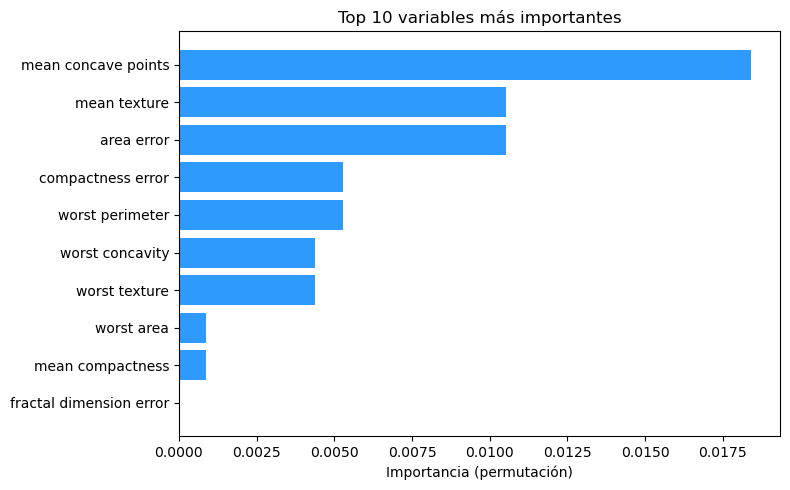

In [49]:
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

result = permutation_importance(gb, X_test, y_test, n_repeats=10, random_state=42)
idx = np.argsort(result.importances_mean)[-10:]   # top 10
names = load_breast_cancer().feature_names

plt.figure(figsize=(8, 5))
plt.barh(range(len(idx)), result.importances_mean[idx], color='#2E9AFE')
plt.yticks(range(len(idx)), names[idx])
plt.xlabel('Importancia (permutación)')
plt.title('Top 10 variables más importantes')
plt.tight_layout()
plt.show()

## Hiperparámetros clave

| Hiperparámetro | Efecto | Recomendación |
|---|---|---|
| `n_estimators` / `max_iter` | Número de árboles | Más árboles + `learning_rate` bajo |
| `learning_rate` | Contribución de cada árbol | 0.01 – 0.1 (más bajo = más robusto) |
| `max_depth` / `num_leaves` | Complejidad de cada árbol | Controla el sobreajuste |
| `subsample` | Fracción de filas por árbol | 0.8 – 1.0 |
| `colsample_bytree` | Fracción de columnas por árbol | 0.8 – 1.0 |
| Regularización (`reg_lambda`, `reg_alpha`) | Penaliza la complejidad | Aumentar si hay overfitting |

> Estrategia típica: usar **muchos árboles** con un **learning rate pequeño** y detener el entrenamiento con *early stopping*.